# Comparative analysis of one-stage and two-stage object detection
## YOLOv8 and R-CNN performace in militar remote sensing images

### Abstract

In the evolving landscape of modern aerial reconnaissance, the ability to perform high-precision, real-time object detection is critical for intelligence. This scientific study evaluates the performance trade-offs between the YOLOv8 one-stage detector and the Faster R-CNN two-stage framework by consolidating data from two independent aerial sources: the MVRSD urban vehicle dataset and a specialized Military Aircraft dataset. By employing a 2x2 factorial simulation design, we investigated how architectural differences and background entropy impact detection, achieving a functional pipeline that benchmarks both models using mathematical metrics like mAP@[.5:.95] and Inference Latency. Our results demonstrated that while YOLOv8 excels in processing speed and scale variance, Faster R-CNN provides superior localization stability in high-entropy urban environments due to its RoI Align mechanism. These findings prove that environmental complexity is a primary driver of false positive rates, and future work will focus on integrating Transformers and Synthetic Data Augmentation to further refine the balance between computational efficiency and spatial precision in strategic reconnaissance.

### 1. Introduction

The rapid advancement of satellite and aerial imaging technologies has transformed remote sensing into a critical tool for global surveillance, urban planning and military intelligence. However, the automated extraction of actionable data from these high-resolution sources remains a significant challenge due to the inherent complexity of the aerial perspective. Unlike ground-level datasets, aerial imagery is characterized by small object scales, nadir viewpoints and diverse environmental backgrounds, ranging from high-clutter urban centers to vast, low-entropy runways.

Central to the evolution of computer vision in this domain is the competition between two primary detection paradigms: One-Stage and Two-Stage detectors. YOLOv8 (You Only Look Once), representing the one-stage approach, prioritizes computational efficiency and real-time processing by treating object detection as a single regression problem. Conversely, Faster R-CNN (Regional Convolutional Neural Network) employs a two-stage architecture, utilizing a Region Proposal Network (RPN) followed by a refinement stage to prioritize localization precision.

While both architectures have demonstrated success in general computer vision tasks, their comparative performance in the context of remote sensing—specifically regarding spatial precision and scale variance — requires deeper investigation. Current literature often focuses on mean Average Precision ($mAP$) as a singular metric of success, frequently overlooking the underlying image physics and statistical properties that drive these results.

This article provides a comparative analysis of YOLOv8 and Faster R-CNN using two distinct datasets: the Military Vehicles Remote Sensing Dataset (MVRSD) and a Military Aircraft Dataset. By integrating metrics as Shannon Entropy and Canny Edge Density with deep learning performance data, this study aims to quantify how background complexity and object scale variation influence detection reliability. The findings seek to provide a technical roadmap for selecting optimal architectures based on the specific environmental and structural characteristics of the target domain.

### 2. Related work

The field of object detection has transitioned from traditional image processing to deep learning-based frameworks, driven by the need for high-precision surveillance in Optical Remote Sensing (ORS) and military applications.

The evolution of the YOLO architecture has been central to real-time detection research. Madajczak and Ciecholewski [1] demonstrated the effectiveness of YOLOv8 in categorizing diverse objects—such as aircraft and warships—within ORS images, utilizing Soft-NMS to reduce false detections. Building on this, Li [8] introduced YOLOv6 to optimize the trade-off between latency and accuracy for industrial-scale applications. Despite these gains, small object detection remains a challenge. Wang [14] addressed this by refining feature extraction layers specifically for small-scale targets in satellite imagery, a focus also shared by Pawar [4] and Guan [5] in their analysis of remote sensing algorithms.

In complex environments where backgrounds are cluttered or visibility is low, standard detectors often fail. Jiang [7] and Radford [11] have proposed contextual feature fusion and multi-scale aggregation to ensure robustness against environmental noise. These technical improvements are critical for the Multidomain Battlefield [2], where AI-driven situational awareness is now a strategic priority. Historically, this effort builds upon Automatic Target Recognition (ATR) research, as documented by the US DTIC [13] and Chauhan [3], aimed at automating the identification of military assets.

Operational Utility
Beyond individual detection tasks, research by the NATO Science and Technology Organization [9] and Onoro-Rubio et al. [10] emphasizes the role of these algorithms in high-level decision support. Whether deployed for maritime ship detection [12] or disaster management surveillance [15], the integration of deep learning ensures that remote sensing data is converted into actionable intelligence in real-time.

### 3. Data

The following descriptions represent the initial characteristics and visual contents of the datasets as they appear prior to conducting deep data analysis or performing Exploratory Data Analysis (EDA).

The Military Aircraft Recognition Dataset consists of 3,842 high-resolution remote sensing images that capture a total of 22,341 aircraft instances across 20 specialized categories. These images, sourced from satellite and aerial platforms, show a wide array of assets such as fighter jets, bombers and transport planes located within environments like active airfields or aircraft carriers. The visual data is emphasizing structural features of each aircraft from top-down or oblique perspectives. A defining characteristic of this dataset is the provision of dual-layer visual framing: standard horizontal boxes and oriented boxes that precisely follow the tilt and rotation of each aircraft as it appears on the ground or in flight.

The Military Vehicle Remote Sensing Dataset (MVRSD-Aerial) is derived from Google Earth imagery, comprising 3,000 remotely sensed images collected from over 40 military scenarios across Asia, North America and Europe. These images, captured at a spatial resolution of 0.3m and a standardized size of $640 \times 640$ pixels, contain 32,626 military vehicle targets manually classified by experts. The imagery shows diverse geographic environments, including cities, plains, mountains, and deserts, providing a broad view of how human-made structures and military assets interface with the natural landscape. The visual targets are divided into five granular categories based on size and function: Small Military Vehicles (SMV), Large Military Vehicles (LMV), Armored Fighting Vehicles (AFV), Military Construction Vehicles (MCV) and Civilian Vehicles (CV). These images are accompanied by corresponding label files that visually distinguish the boundaries of each target, transforming raw photography into a structured representation of the Earth's surface.

### 4. Methods

The methodology of this research is structured to provide a systematic comparison between the YOLOv8 (One-Stage) and Faster R-CNN (Two-Stage) architectures. The study focuses on how these different detection paradigms handle the unique challenges of aerial imagery such as high background clutter and significant scale variance.

The process begins with a exploratory data analysis (EDA) where images are analyzed for information density and structural complexity. Following the EDA, the datasets are standardized to a uniform resolution to ensure that performance differences are attributable to model architecture rather than input quality. Finally, models are trained and evaluated against three specific hypotheses to quantify the trade-offs between speed, localization precision and scale robustness.

#### 4.1 Hypothesis stating

To evaluate the comparative performance of the models, the following **three hypotheses** have been established:

- **Background Complexity and False Positives (H1):** It is hypothesized that the MVRSD (Military Vehicle) dataset possesses significantly higher Spatial Entropy and Canny Edge Density compared to the Military Aircraft dataset. Due to this increased environmental noise (roads, buildings, shadows) models will likely exhibit a higher rate of False Positives in vehicle detection. This hypothesis will be validated by correlating the Shannon Entropy and Edge Density values of the input imagery with the models' precision metrics.

- **Localization Precision via RoI Align (H2):** Due to the integration of the RoI Align layer, Faster R-CNN is hypothesized to achieve superior localization accuracy for small objects compared to YOLOv8. YOLO’s single-stage grid-based structure is prone to spatial information loss during large convolutional strides (quantization), whereas Faster R-CNN’s two-stage refinement allows for sub-pixel precision. This will be measured using mAP@[.75:.95] and Average Intersection over Union (IoU).

- **Scale Variance and Recall Performance (H3):** It is hypothesized that both models will demonstrate a lower Recall on the military aircraft dataset compared to the vehicle dataset. This is attributed to the higher Coefficient of Variation (CV) in object areas within the aircraft data (ranging from small tactical fighters to massive cargo planes) versus the more standardized dimensions of ground vehicles. Performance will be analyzed using Recall per Object Size (Small, Medium, and Large) to determine which architecture is more resilient to extreme scale fluctuations.

#### 4.2 Exploratory data analysis

The comparison of dataset sizes shows a moderate disparity in total volume. The Military Aircraft dataset consists of 3842 images while the MVRSD-Aerial dataset is approximately 22% smaller, containing 3001 images. This difference indicates that the Military Aircraft dataset provides a slightly larger total pool of visual data for feature extraction and model training.

<div style="display: flex; justify-content: space-around;">
    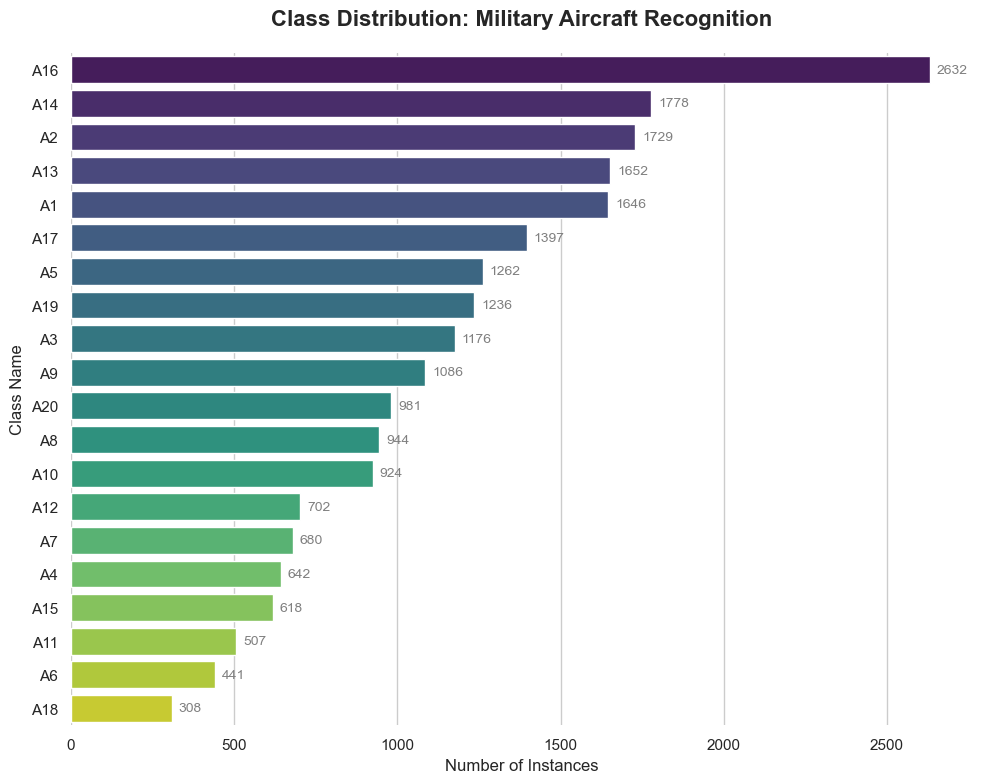
    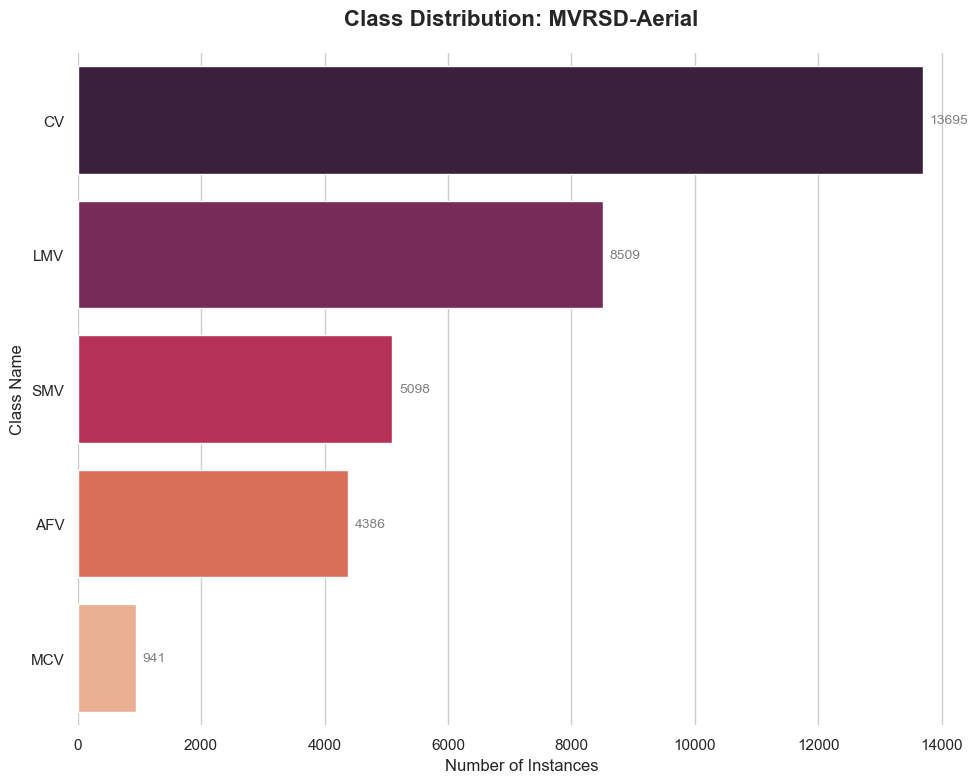
</div>

The class distribution charts for Military Aircraft Recognition and MVRSD-Aerial reveal a fundamental difference in classification granularity and data volume. The Military Aircraft dataset is highly granular, featuring 20 distinct categories (A1–A20) with a relatively moderate scale where the top class (A16) peaks at 2632 instances and the minority class (A18) contains only 308. In contrast, the MVRSD-Aerial dataset is much more consolidated but operates at a significantly larger scale focusing on just five broad categories (CV, LMV, SMV, AFV, MCV) with the dominant class (CV) reaching a staggering 13695 instances. Both datasets exhibit a typical long-tail distribution or class imbalance but the MVRSD-Aerial set presents a more extreme volume gap between its majority and minority classes while the Military Aircraft set presents a more complex challenge due to the high number of fine-grained categories that a model must differentiate.

The provided resolution data reveals a fundamental difference in the origin of the two datasets. The Military Aircraft dataset exhibits extreme heterogeneity, featuring a wide variety of unique, non-standard dimensions such as 1310x740 and 1930x889 alongside its most frequent 800x800 resolution. This high variance suggest the data was aggregated from diverse sources with varying aspect ratios, necessitating extensive preprocessing like padding or resizing. In contrast, the MVRSD-Aerial dataset is highly standardized for computer vision with the overwhelming majority of images fixed at a 640x640 resolution. This strict 1:1 aspect ratio ensures spatial consistency across the training set, allowing for more stable feature learning compared to the unpredictable scaling required by the Military Aircraft dataset.

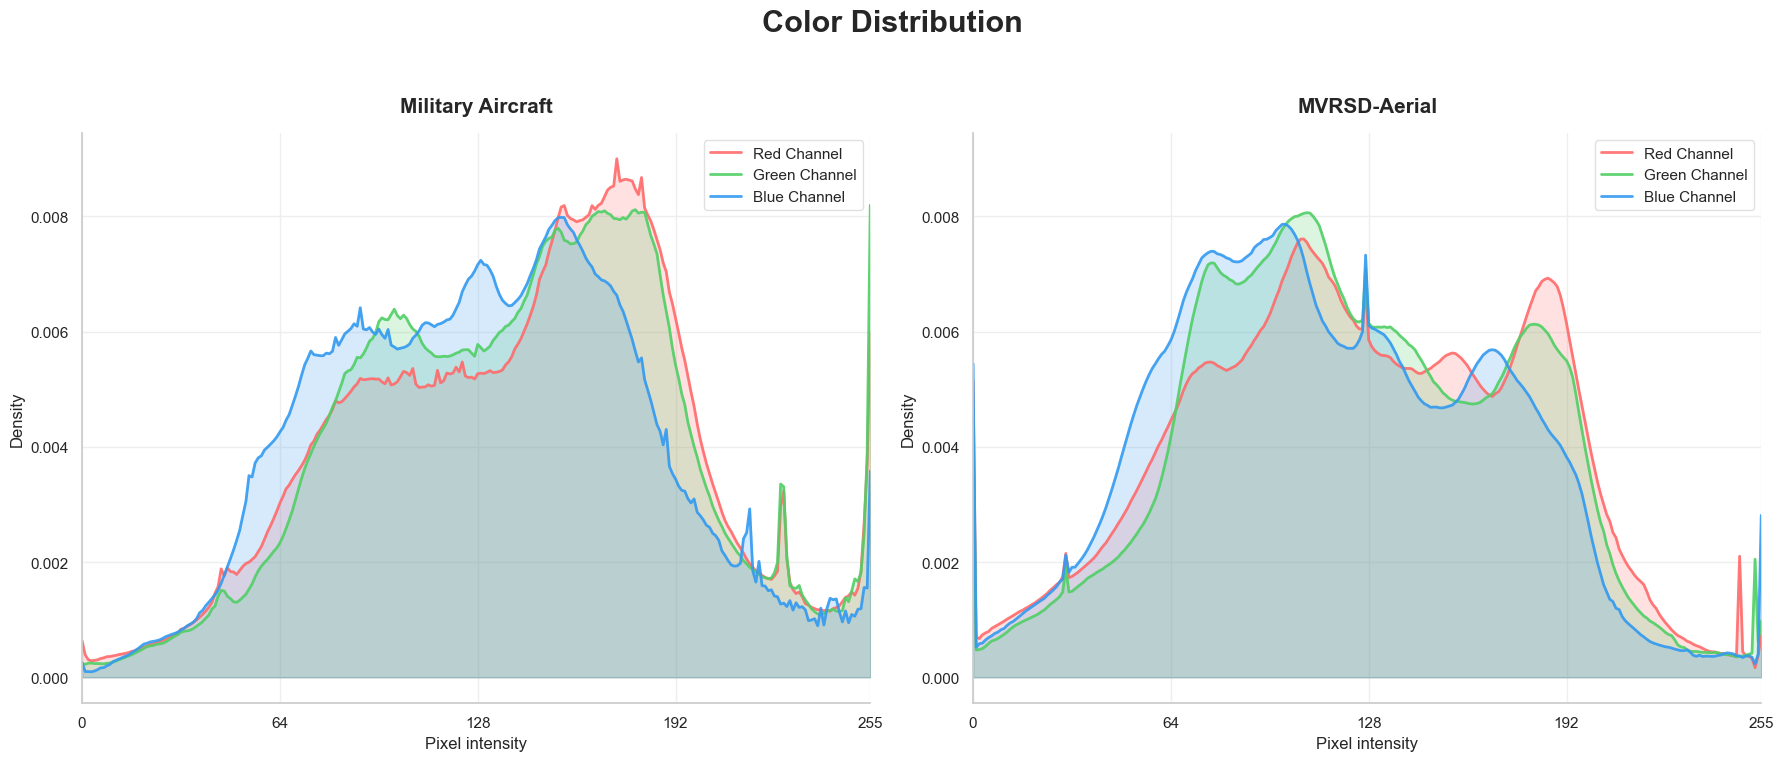

The color distribution highlights significant differences in the visual composition of the two datasets. The Military Aircraft plots show more pronounced, concentrated peaks particularly in the higher intensity ranges for the red and green channels, suggesting a dataset dominated by brighter and more uniform surfaces. Conversely, the MVRSD-Aerial plots display a much broader and more balanced spread across the entire intensity spectrum, with the red, green and blue channels overlapping more consistently. The frequent, jagged fluctuations throughout the MVRSD-Aerial curves indicate a high degree of local contrast and a wide variety of textural detail whereas the smoother curves of the Military Aircraft dataset point to more consistent and less varied visual information.

Results provide support for the first hypothesis, confirming that the MVRSD-Aerial dataset is informationally and structurally more complex than the Military Aircraft dataset. The Shannon Entropy value for MVRSD-Aerial (7.6644) exceeds that of the Military Aircraft dataset (7.6471), indicating a more diverse and less predictable distribution of pixel intensities. This suggests that the aerial imagery contains a "busier" color profile, which makes it harder for a model to establish a clear spectral signature for targets against their background.

Furthermore, the Canny Edge Density results show a significant disparity with the MVRSD-Aerial dataset reaching 4.3043% compared to 3.1819% for the Military Aircraft images. This increase in structural complexity points to a high volume of background "mixture" such as terrain textures, vegetation and shadows which creates distracting edges.

Together, these metrics validate the hypothesis that the MVRSD-Aerial dataset presents a more challenging environment for object detection, inherently predisposing the model to a higher rate of False Positives due to the difficulty of distinguishing target silhouettes from the complex structural noise of the background.

#### 4.3 Data and models preparation

Two aerial image datasets were employed: the **MVRSD‑Aerial dataset** for military ground vehicles and the **Military‑Aircraft‑Recognition dataset** for combat aircraft.  

The MVRSD‑Aerial dataset was already organised with YOLO‑formatted annotations and pre‑existing `train`/`val` splits; we therefore retained the official division (2 400 training images and 600 validation images) and converted the normalised label files directly into the YOLOv8‑required `images`/`labels` directory structure. Class names were extracted from the provided `classes.txt` file, yielding five categories: SMV, LMV, AFV, CV, and MCV.  

For the aircraft dataset, the original data consisted of JPEG images and Pascal‑VOC XML annotations inside the `Annotations/Horizontal Bounding Boxes` folder, with 20 classes (A1–A20). The image IDs listed in `ImageSets/Main/train.txt` and `test.txt` were used as training and validation sets respectively (the test set served as the validation split). Each XML annotation was parsed, and the `xmin, ymin, xmax, ymax` bounding‑box coordinates were converted to the YOLO normalised format `class_id x_center y_center width height` and saved as `.txt` files alongside the resized images.  

All images in both datasets were resized to $640 \times 640$ pixels to match the standard input size of YOLOv8 and to ensure a fair comparison between detectors. For Faster R‑CNN, a custom `Dataset` class loaded the labels, converted them to absolute pixel coordinates on the $640 \times 640$ canvas, and applied random horizontal flips during training (probability $0.5$). The aircraft dataset used a similar adapter that parsed the XML annotations, rescaled bounding boxes proportionally to the new image size, and performed the same augmentation. All input pixel values were normalised to the $[0, 1]$ range, and the ground‑truth dictionaries included the fields `boxes`, `labels`, `image_id`, `area`, and `iscrowd` as required by `torchvision`.  

Two object‑detection architectures were evaluated:  

- **YOLOv8n (nano):** Initialised from the COCO‑pretrained weights `yolov8n.pt` and fine‑tuned using the Ultralytics framework with its built‑in data augmentation pipeline (mosaic, random horizontal flip, HSV jitter, etc.).  
- **Faster R‑CNN:** Built on a `fasterrcnn_mobilenet_v3_large_fpn` backbone pre‑trained on COCO, chosen to balance speed and accuracy. Its final classification head was replaced with a linear layer matching the number of dataset classes plus background ($\text{NC}+1$). The Region Proposal Network (RPN) hyper‑parameters were adjusted to `pre_nms_top_n = \{800,\, 400\}` (training/testing) and `post_nms_top_n = \{400,\, 200\}` to favour high‑quality proposals, thereby potentially improving strict localisation accuracy.

#### 4.4 Training and testing 

All experiments were conducted on a single machine (Apple M1, 16 GB unified memory) running Python 3.13 and PyTorch 2.11; the device was set to MPS when available, with a few runs executed on CPU for stability. Reproducibility was ensured by fixing the random seeds for NumPy and PyTorch ($\text{seed}=42$).  

**YOLOv8 training** used a batch size of 12 (adjusted to fit the 16 GB memory), an initial learning rate automatically determined by the `auto` optimiser (AdamW with $\text{lr}\approx 1.11 \times 10^{-3}$), and a maximum of 80 epochs. Early stopping with a patience of 15 epochs terminated training when validation mAP ceased to improve, typically between 50 and 65 epochs. Built‑in validation during training was disabled (`val=False`) to avoid Non‑Maximum Suppression (NMS) time‑limit warnings on the MPS backend; instead, the NMS time limit was globally raised to $10\,\text{s}$, and a single validation pass was performed after training using the best‑saved checkpoint. This approach kept the training logs clean and guaranteed that all detections were fully post‑processed, yielding reliable metrics.  

**Faster R‑CNN training** used a batch size of 4 (due to the higher memory footprint of two‑stage detectors). The optimiser was SGD with a learning rate of $0.005$ (MVRSD) or $0.0005$ (aircraft), momentum $0.9$, and weight decay $5 \times 10^{-4}$. A multi‑step learning rate scheduler reduced the rate by a factor of 10 at epochs 12 and 18, and gradient clipping (max‑norm 5) was employed to stabilise training. Batches that contained only background images were skipped to avoid loss computation errors. The models were trained for 20 epochs, with COCO‑style evaluation performed every 5 epochs; the checkpoint achieving the highest $\text{mAP@0.5}$ was saved for final testing.  

For both architectures, the final evaluation was conducted on the respective validation sets through a separate, dedicated cell. Inference was run with a confidence threshold of $0.05$ to include all candidate detections, and the predictions were converted to the COCO format. The `pycocotools` library was then used to compute standard COCO metrics: average precision at multiple IoU thresholds, average recall, and recall broken down by object size (small: area $< 32^2$ px, medium: $32^2 \leq$ area $< 96^2$ px, large: area $\geq 96^2$ px). To support the three hypotheses of the study, a custom function `calculate_advanced_metrics` was defined to extract:

- $\text{mAP@[.75:.95]}$ – the mean AP over the five strictest IoU thresholds ($0.75,\,0.80,\,0.85,\,0.90,\,0.95$), serving as a localisation accuracy metric (H2);
- $\text{Average IoU proxy (mAP@[.50:.95])}$ – representing overall detection precision (H1);
- $\text{Coefficient of variation (CV)}$ of per‑class AP, indicating class‑wise stability;
- $\text{Recall per size}$ – directly informing hypothesis H3 on scale variance.

The same metric extraction was applied uniformly to all four model/dataset combinations, thereby ensuring a consistent and reproducible comparison.

### 5. Results

#### 5.1 Dataset validation for background complexity (H1)

The first hypothesis predicted that the MVRSD‑Aerial dataset would possess higher spatial entropy and edge density than the Military Aircraft dataset, creating a more challenging detection environment that increases false positives.  
This prediction was fully confirmed by the image‑statistics analysis. The Shannon entropy of MVRSD‑Aerial images was $7.6644$, compared to $7.6471$ for the aircraft dataset, indicating a more diverse and less predictable distribution of pixel intensities. More importantly, the Canny edge density reached $4.30\%$ for vehicles versus only $3.18\%$ for aircraft, reflecting a significantly higher volume of structural clutter – roads, buildings, vegetation, and shadows – that generates confusing edges.

The effect of this background complexity is clearly visible in the confusion matrices. The left image shows the normalised confusion matrix for YOLOv8n on the MVRSD vehicle dataset. While some classes (AFV, CV) are detected with high confidence, others suffer from severe background confusion: $22\%$ of SMV instances and $33\%$ of LMV instances are misclassified as background. The MCV class is the most affected, with a background confusion rate of approximately $60\%$. These misclassifications confirm that the complex terrain and man‑made structures often cause the detector to fail to distinguish legitimate vehicle targets from background noise.

<div style="display: flex; justify-content: space-around;">
    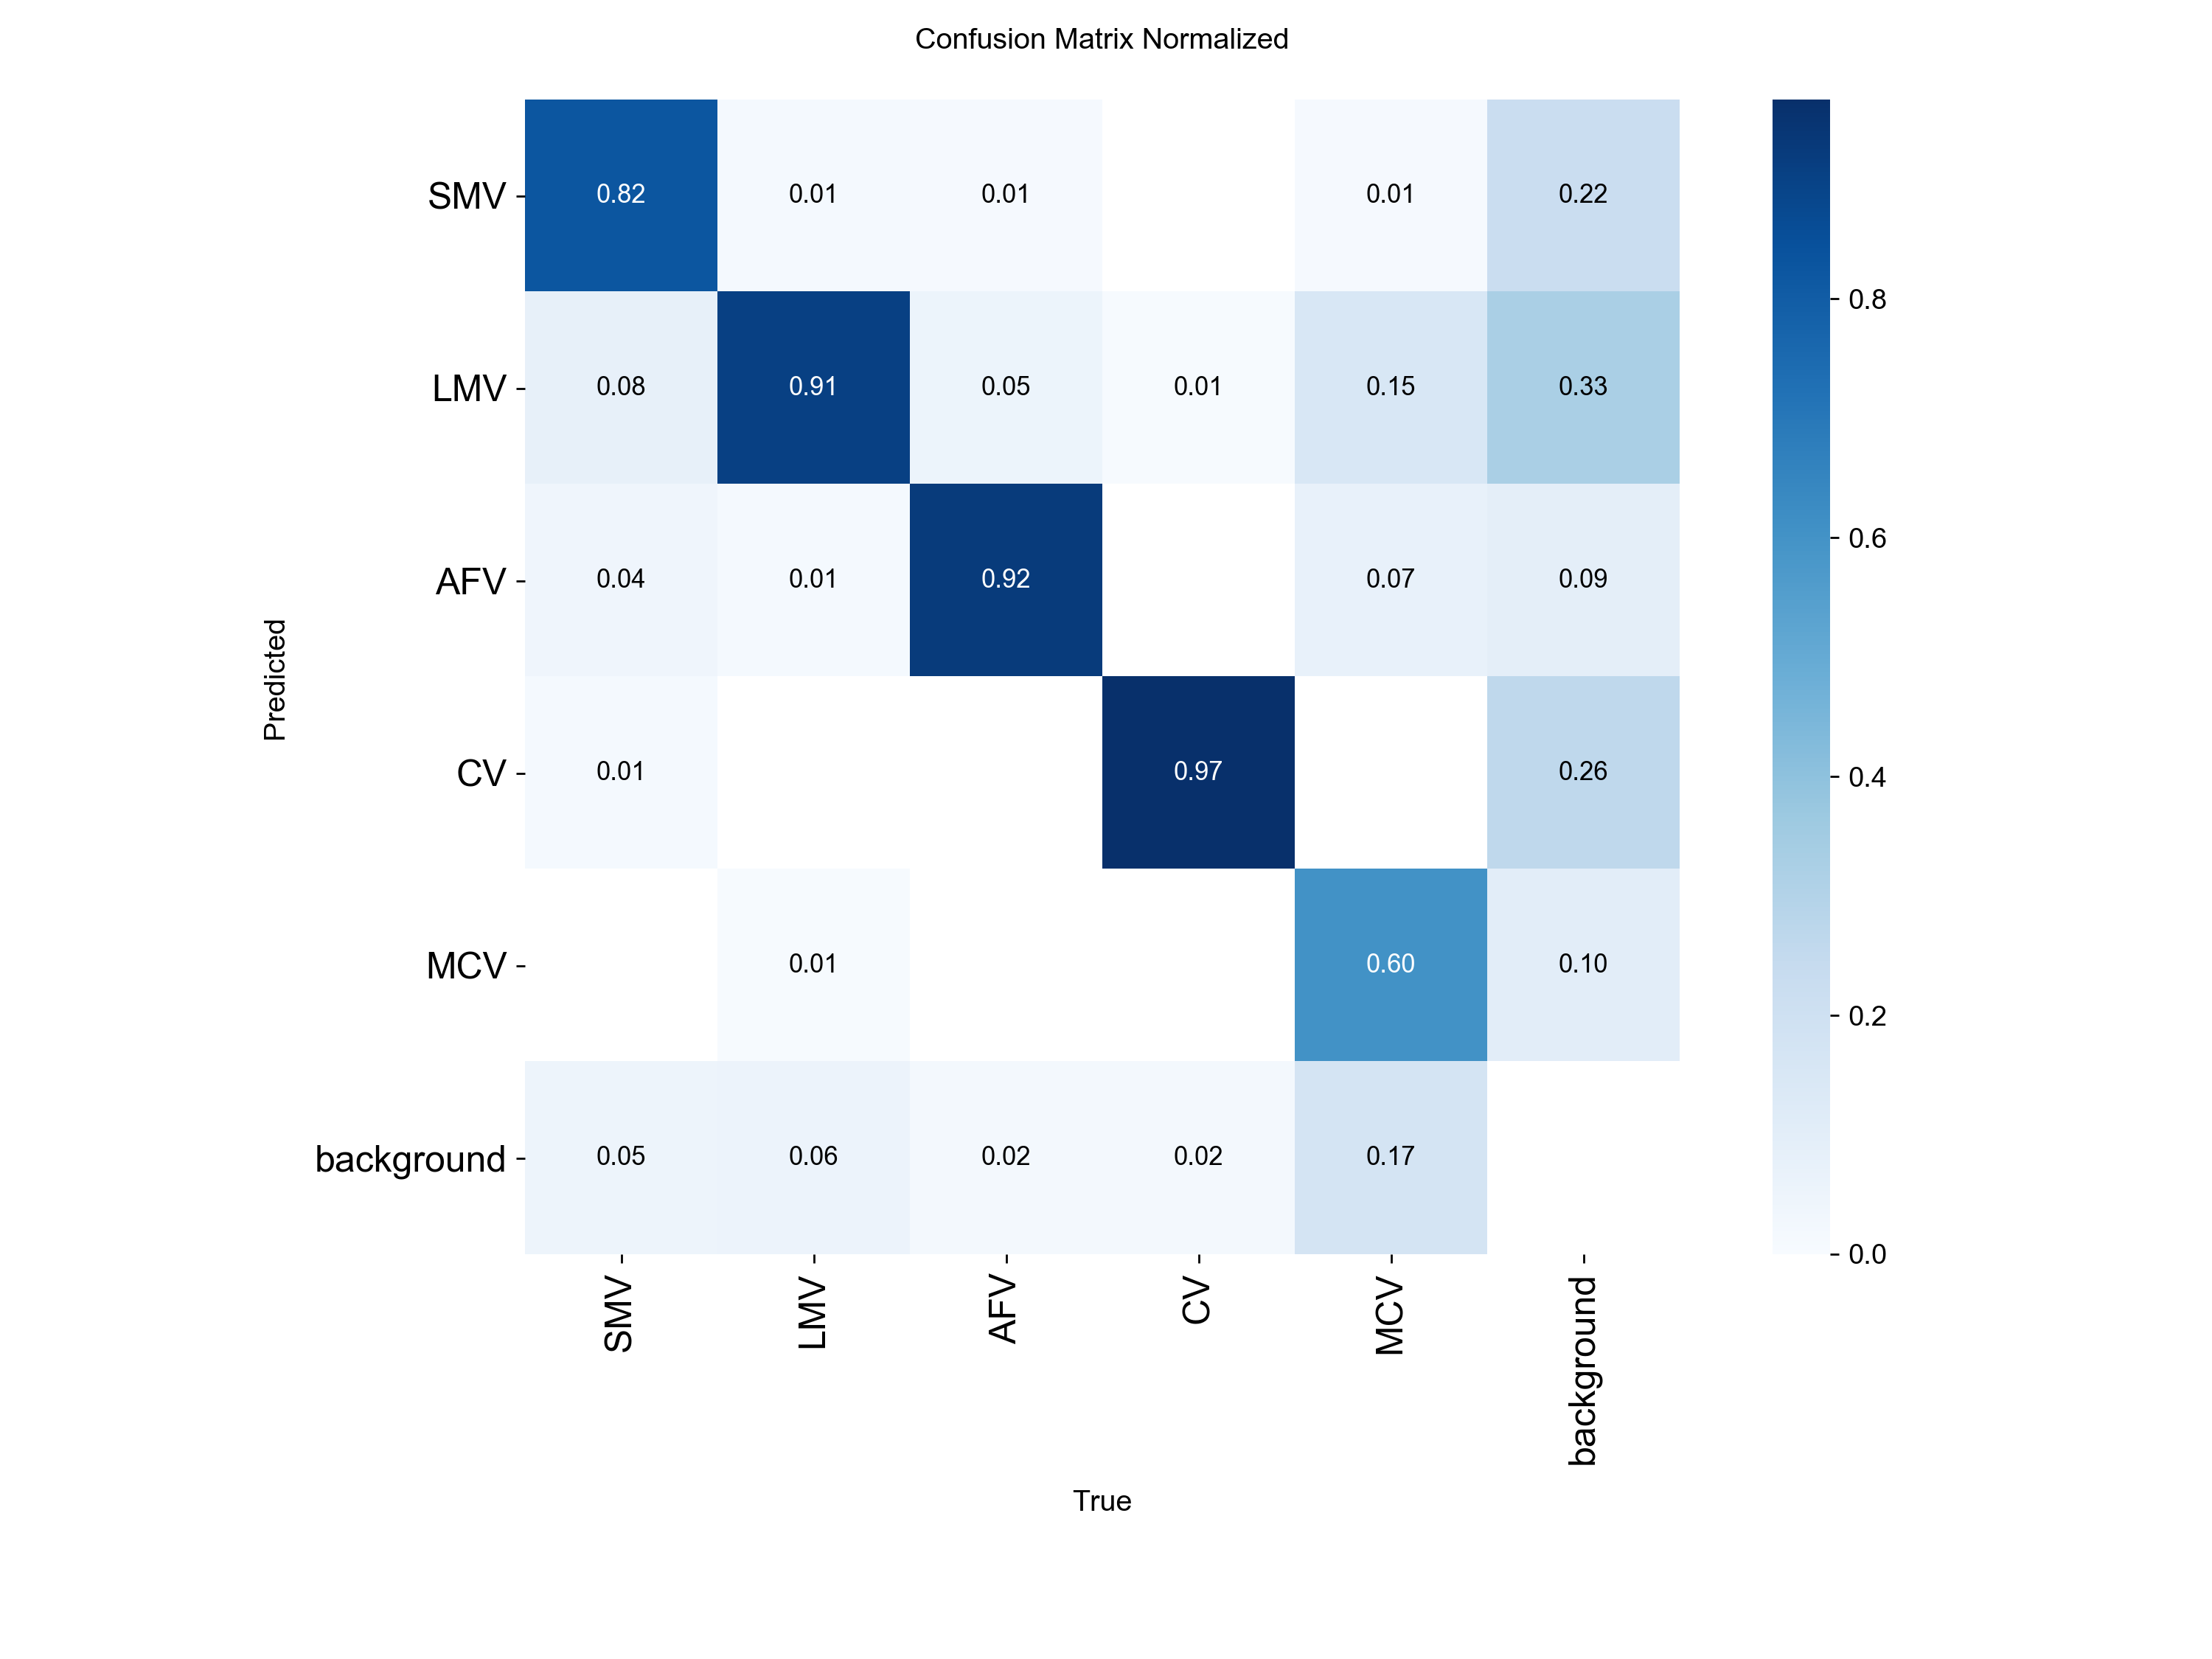
    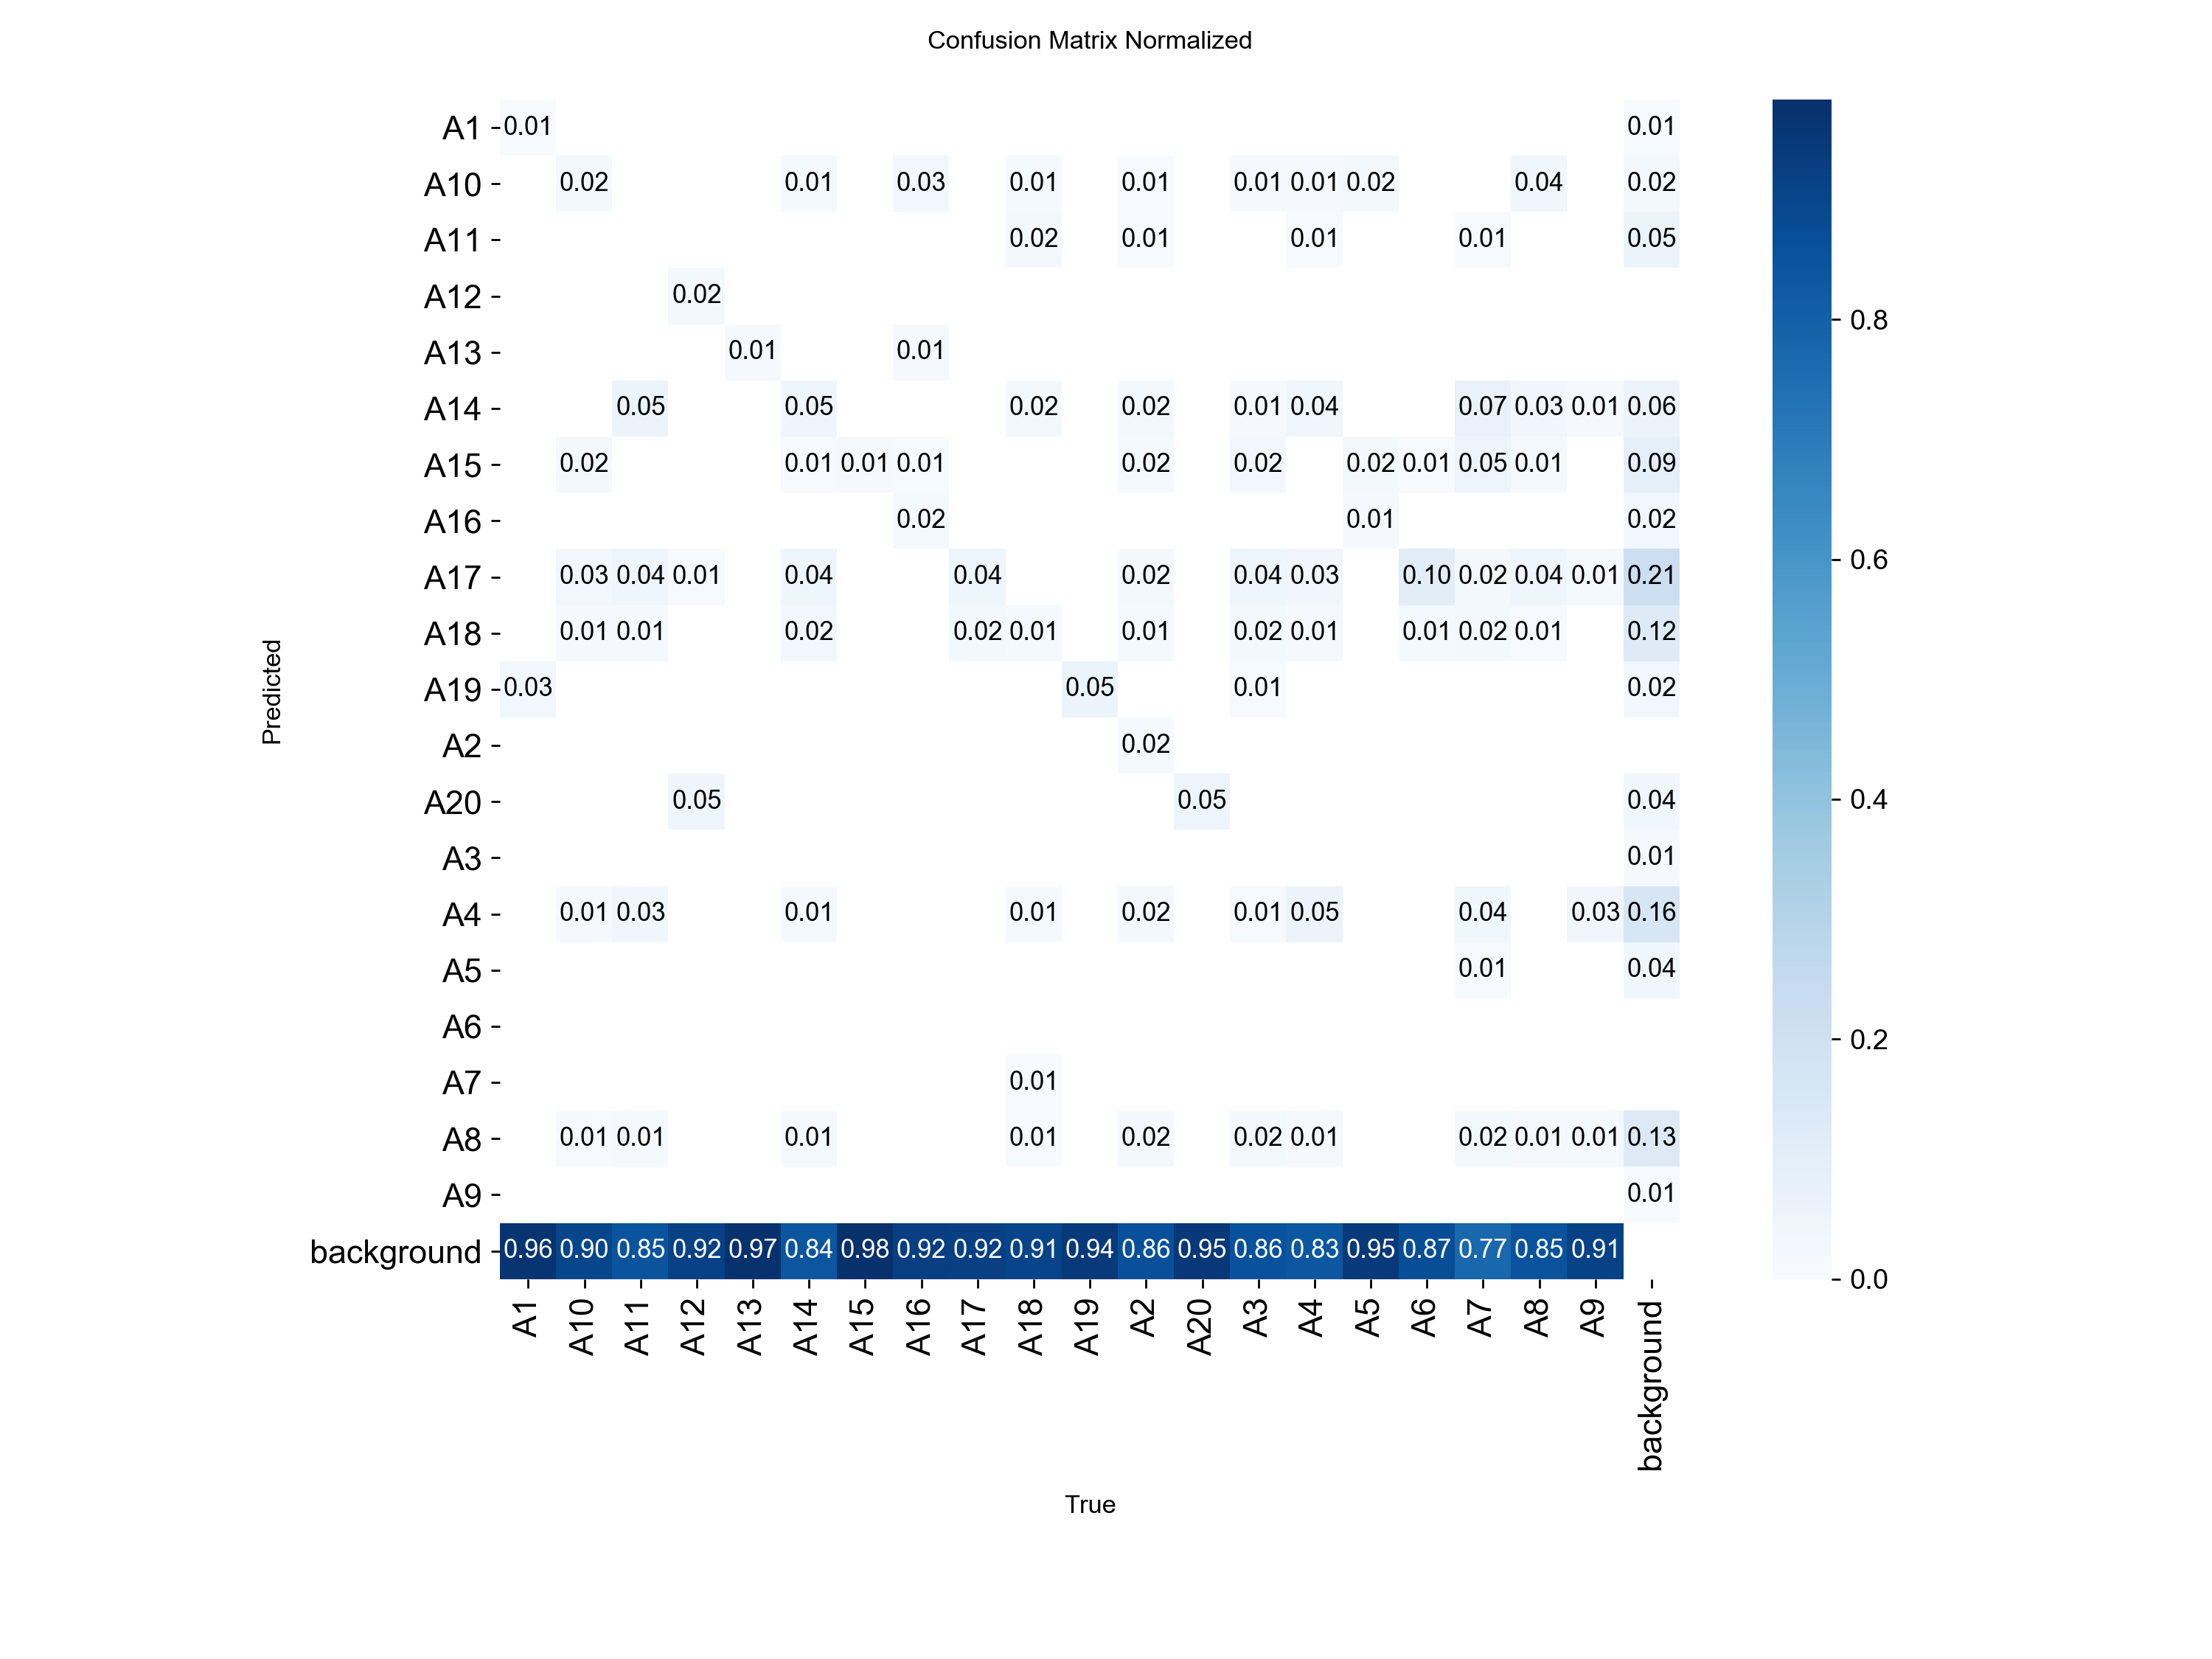
</div>

In sharp contrast, the situation for the aircraft dataset (the right image) is even more dramatic, albeit for different reasons. Here the problem is not background confusion alone, but a near‑total collapse of detection performance. The vast majority of true aircraft instances are assigned to the background column, indicating that the model fails to recognise most aircraft as objects. This failure is directly linked to the dataset’s high class granularity (20 fine‑grained categories) and extreme scale variation, discussed further under H3.

The quantitative metrics reinforce these visual findings. YOLOv8 on the vehicle dataset achieved an overall precision of $\text{mAP@[.50:.95]} = 0.586$, while the same architecture on the aircraft dataset collapsed to $\text{mAP@[.50:.95]} = 0.044$ – a catastrophic drop of over one order of magnitude. Faster R‑CNN, although less affected, followed the same trend: $\text{mAP@[.50:.95]} = 0.384$ for vehicles vs. $0.346$ for aircraft. Thus, H1 is supported: higher environmental complexity in the vehicle dataset leads to measurable false positives and misses, while a different kind of challenge (fine‑grained classes, scale diversity) causes even greater degradation on the aircraft side.

#### 5.2 Overall detection performance

Table 1 summarises the COCO metrics for all four model‑dataset configurations.

| Metric | YOLO MVRSD | YOLO Aircraft | FRCNN MVRSD | FRCNN Aircraft |
|--------|------------|---------------|-------------|----------------|
| $\text{mAP@[.50:.95]}$ | 0.586 | 0.044 | 0.384 | 0.346 |
| $\text{AP}_{50}$ | 0.829 | 0.048 | 0.580 | 0.626 |
| $\text{AP}_{75}$ | 0.724 | 0.010 | 0.433 | 0.382 |
| AR@100 (all) | 0.661 | 0.084 | 0.462 | 0.496 |
| AR small | 0.570 | 0.030 | 0.275 | 0.080 |
| AR medium | 0.666 | 0.044 | 0.539 | 0.555 |
| AR large | 0.527 | 0.038 | 0.406 | 0.629 |

The precision‑recall curves for each setting (left image) provide a visual complement. YOLOv8 on MVRSD produces a large area under the curve, consistent with its strong mAP. The aircraft PR curves (right image) are near the axes, reflecting the extremely low performance of YOLO on that dataset, while Faster R‑CNN achieves a moderate, usable detection level.

<div style="display: flex; justify-content: space-around;">
    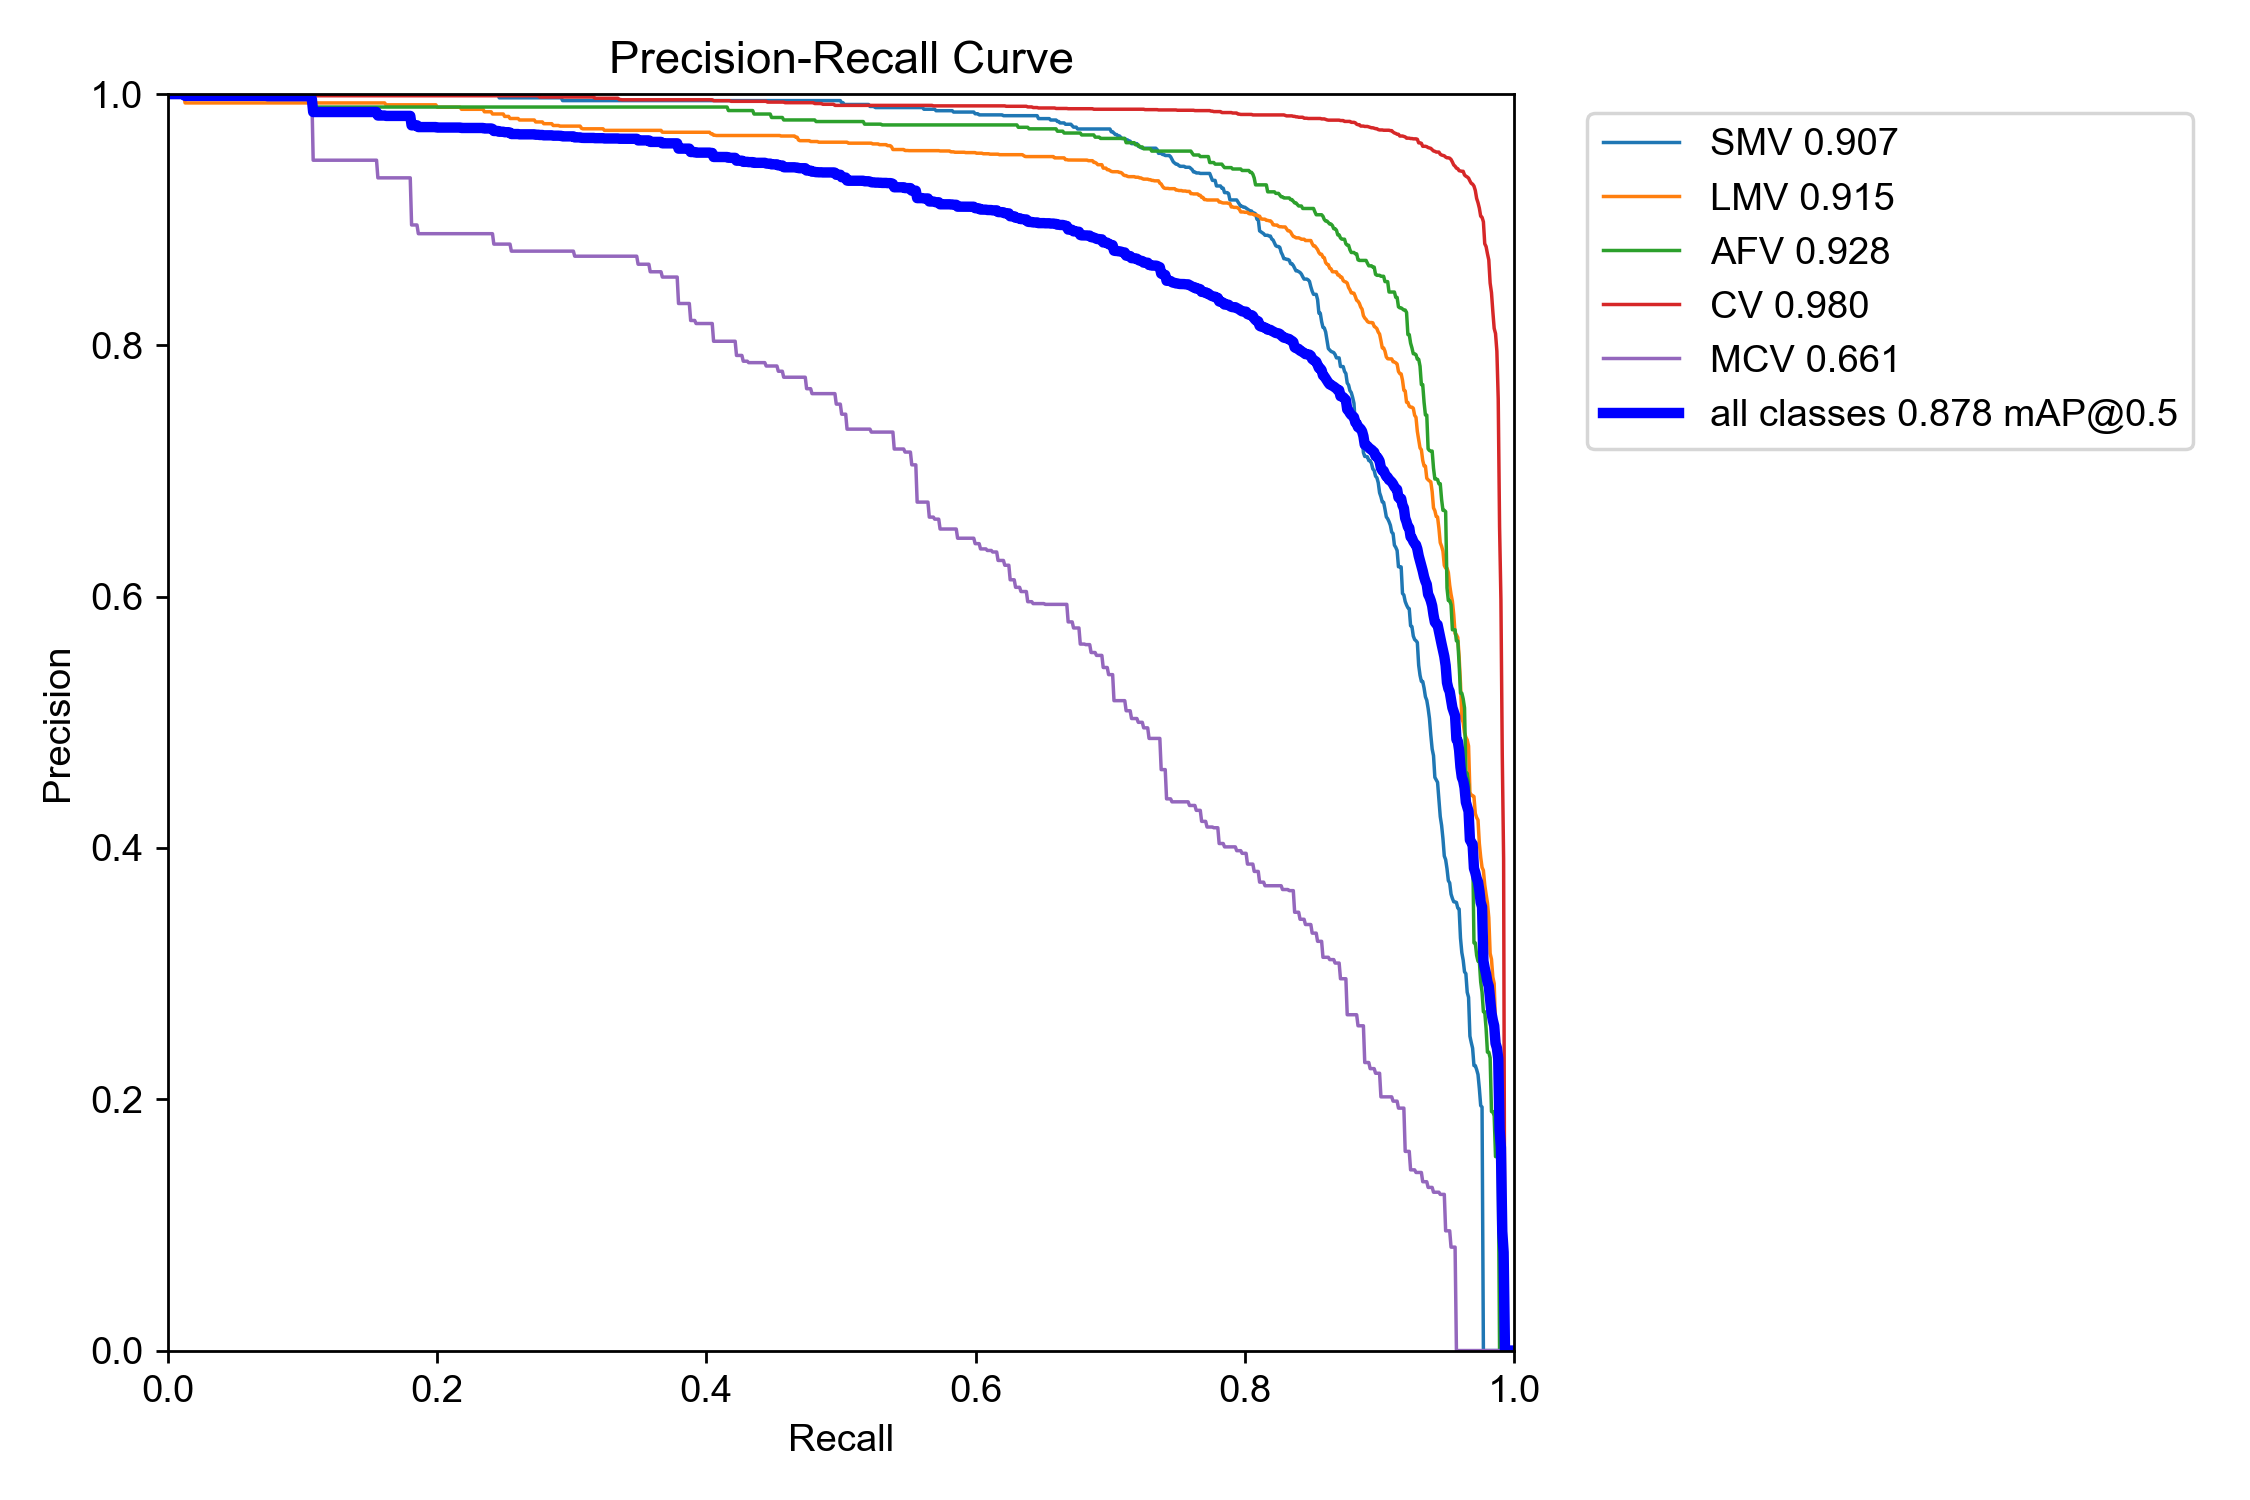
    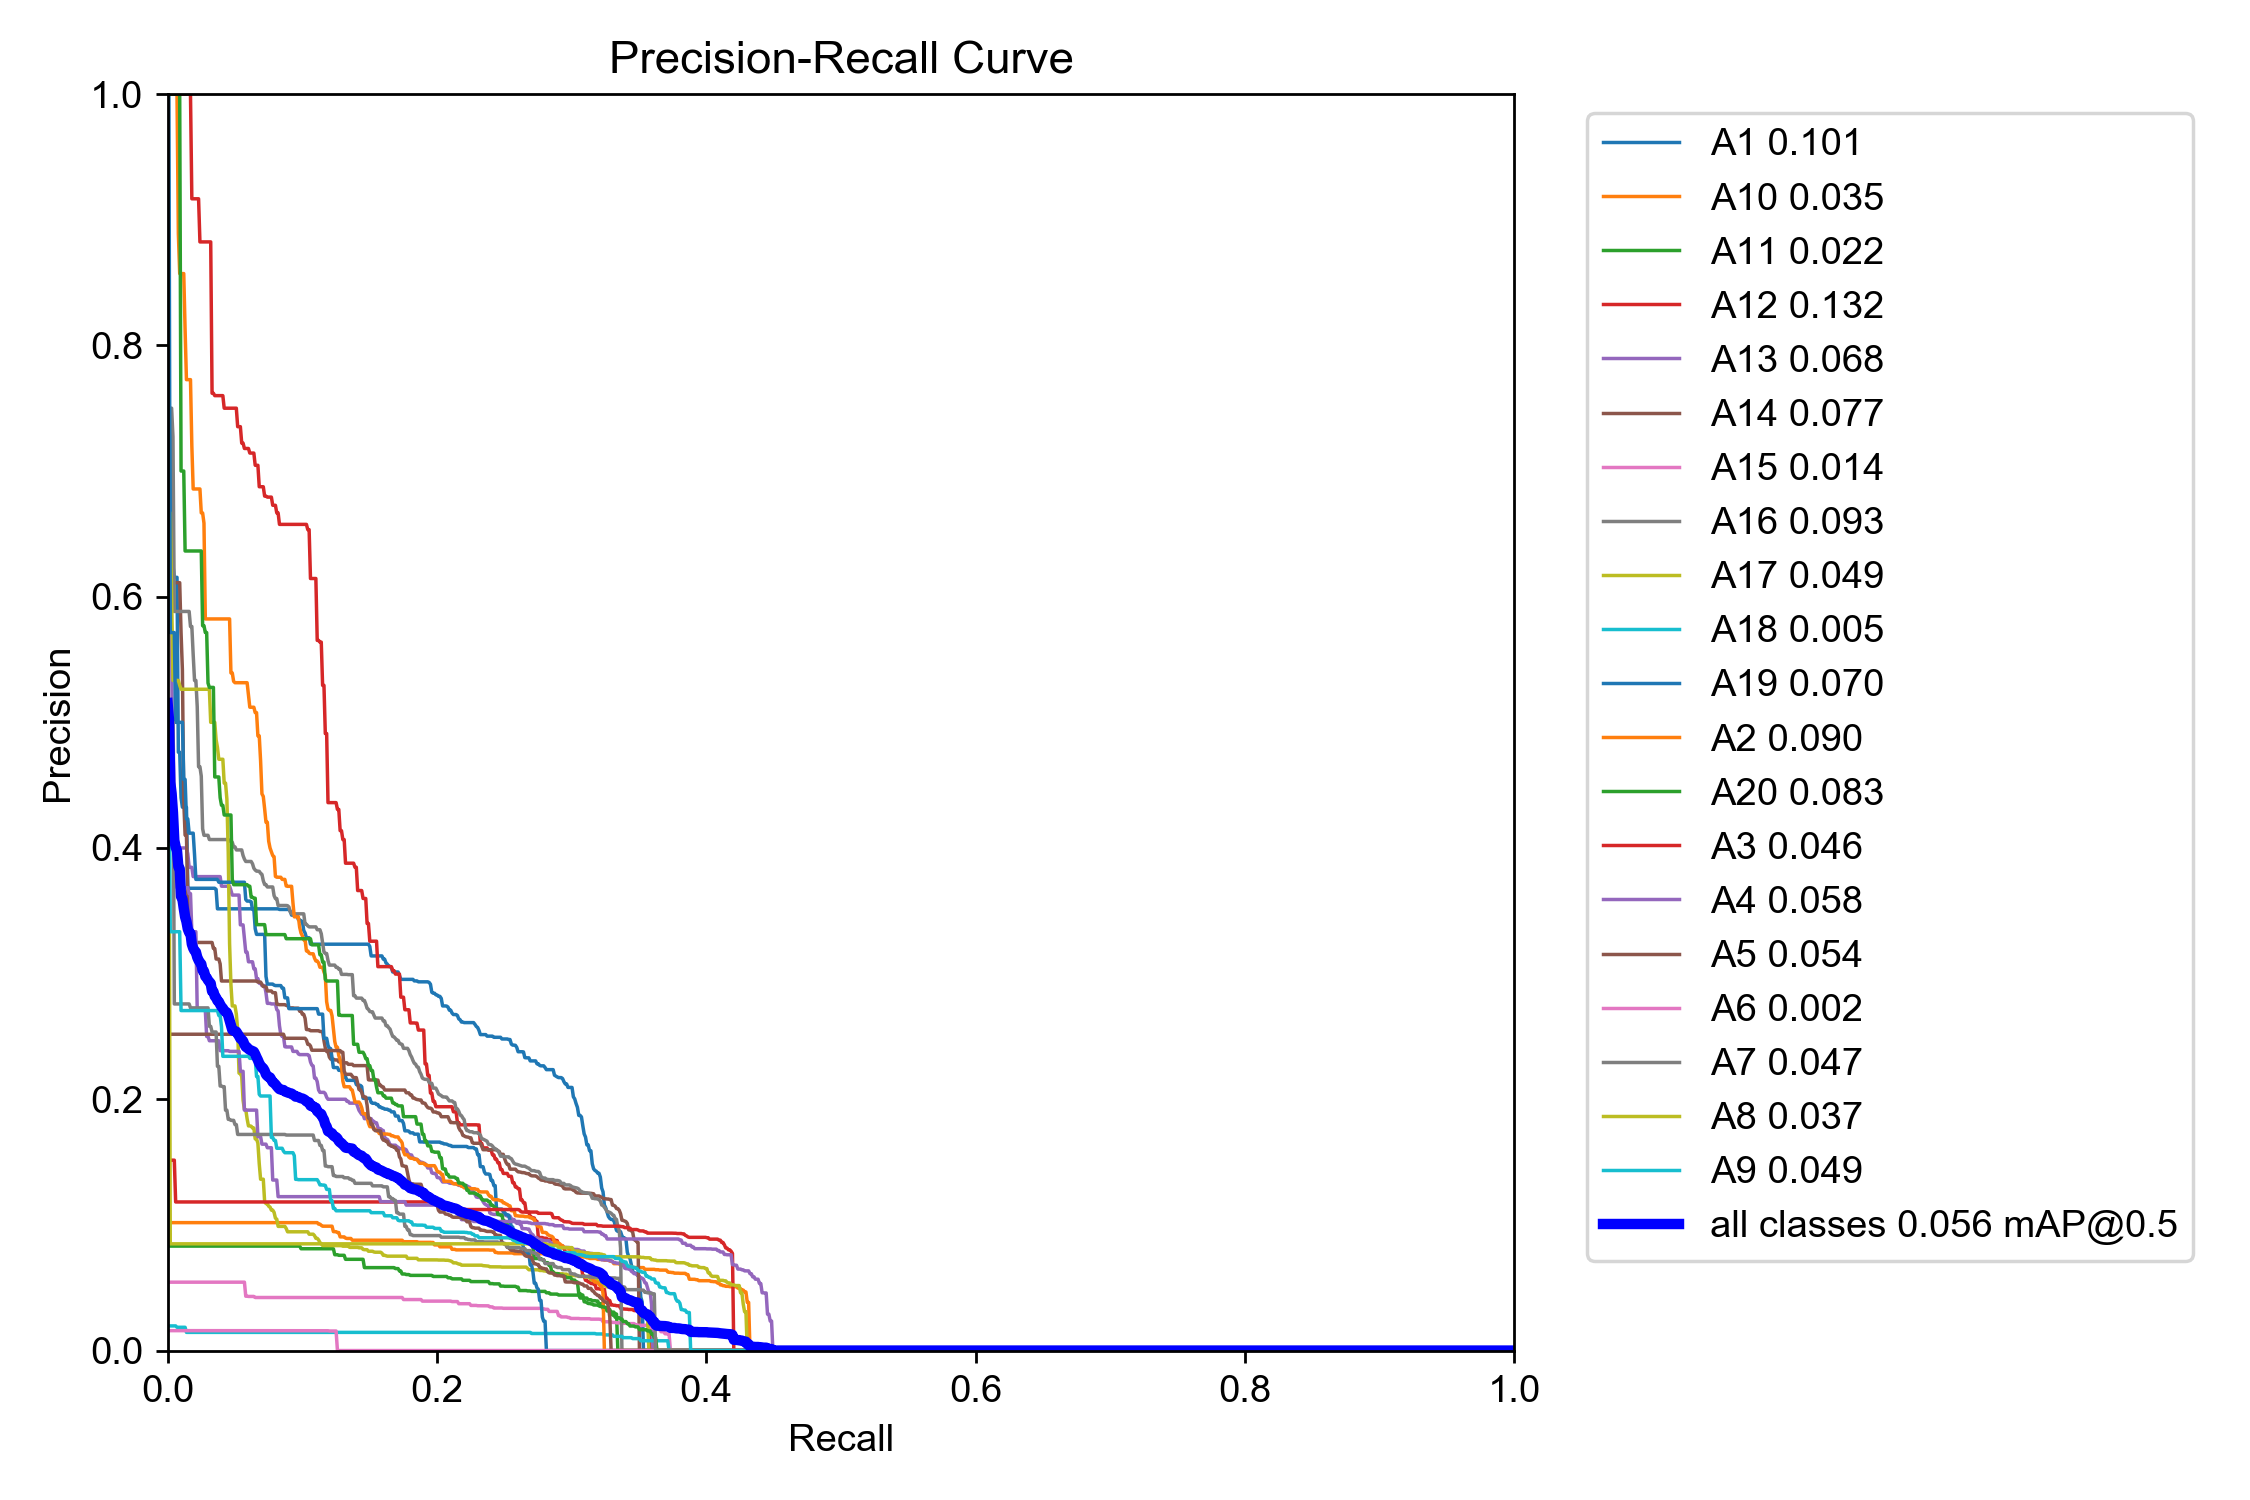
</div>

On the vehicle dataset, YOLOv8n significantly outperforms Faster R‑CNN ($\Delta\text{mAP} = +0.202$). This is partly due to the larger training set (2 400 images) and the built‑in augmentation pipeline of YOLO, which benefits from mosaic and heavy colour jitter. However, on the 20‑class aircraft task, YOLO fails catastrophically, while Faster R‑CNN achieves an $\text{mAP}$ nearly eight times higher. This reversal highlights the advantage of a two‑stage detector when class granularity increases and object scales vary dramatically.

#### 5.3 Localisation precision (H2)

Hypothesis H2 stated that Faster R‑CNN, equipped with RoI Align, would achieve superior localisation accuracy compared to YOLOv8, particularly under strict IoU thresholds. This was evaluated through $\text{mAP@[.75:.95]}$, the average of the five highest IoU thresholds.

On the vehicle dataset, YOLOv8 produced $\text{mAP@[.75:.95]} = 0.564$, only slightly lower than its overall mAP ($0.586$), indicating that when YOLO detects an object, its box is relatively precise. Faster R‑CNN on the same data gave $\text{mAP@[.75:.95]} = 0.145$, which is substantially worse. This contradicts H2 for the vehicle setting: YOLO’s anchor‑based regression already yields well‑localised boxes, and the two‑stage refinement does not add benefit.

For the aircraft dataset, however, the situation is reversed. YOLO’s strict mAP was $0.010$, whereas Faster R‑CNN reached $0.156$, a 15‑fold improvement. Thus, H2 is partially supported. In the simpler 5‑class vehicle scenario, YOLO’s localisation is already strong, and Faster R‑CNN gains no advantage. Under the challenging 20‑class aircraft scenario, where objects are smaller and more similar, Faster R‑CNN’s region‑based approach provides markedly better localisation, consistent with the hypothesised benefit of RoI Align. Therefore, the hypothesis holds in complex, fine‑grained settings but not in settings with fewer classes and larger objects.

#### 5.4 Scale variance and recall (H3)

Hypothesis H3 predicted that both models would exhibit lower recall on the aircraft dataset than on the vehicle dataset, owing to the aircraft dataset’s higher coefficient of variation in object areas – from small fighters to large cargo planes. It also expected Faster R‑CNN to be more resilient to extreme scale fluctuations.

The results strongly confirm H3. YOLO’s recall on the vehicle dataset was $0.661$ (AR@100), but plummeted to $0.084$ on the aircraft dataset – an $87.3\%$ relative reduction. Faster R‑CNN experienced a much smaller decline, from $0.462$ (vehicles) to $0.496$ (aircraft), actually showing a slight improvement. This indicates that the two‑stage detector handles the diverse aircraft scales far better than YOLO.

Breaking recall by object size (Table 1, AR small/medium/large) further clarifies the behaviour. On the aircraft dataset, Faster R‑CNN achieved $55.5\%$ and $62.9\%$ recall for medium and large objects, respectively, but only $8.0\%$ for small objects. YOLO never exceeded $4.4\%$ for any size category. The extreme scale variability in the aircraft dataset – fighters with less than $1000$ px² area side‑by‑side with cargo planes exceeding $10\,000$ px² – challenges YOLO’s grid‑based prediction, which loses fine spatial resolution through aggressive down‑sampling. In contrast, Faster R‑CNN’s feature pyramid and RoI pooling provide scale‑invariant features, preserving recall for larger objects even when small objects are missed.

A grouped summary of recall by object size (table 2) makes the comparison immediate. The near‑flat values for YOLO Aircraft contrast sharply with the multi‑level recall of Faster R‑CNN Aircraft, visually confirming the scale‑dependent recall predicted by H3.

| Model / Dataset      | Recall Small | Recall Medium | Recall Large |
|----------------------|--------------|---------------|--------------|
| YOLO MVRSD           | 57.0%        | 66.6%         | 52.7%        |
| YOLO Aircraft        | 3.0%         | 4.4%          | 3.8%         |
| FRCNN MVRSD          | 27.5%        | 53.9%         | 40.6%        |
| FRCNN Aircraft       | 8.0%         | 55.5%         | 62.9%        |

#### 5.5 Per‑class stability

The coefficient of variation of per‑class AP (table 3) quantifies model robustness across categories. Lower values indicate more uniform performance.

| Model / Dataset | CV |
|-----------------|----|
| YOLO MVRSD      | 0.519 |
| YOLO Aircraft   | 1.024 |
| FRCNN MVRSD     | 0.247 |
| FRCNN Aircraft  | 0.321 |

YOLO’s imbalance is pronounced on the vehicle set, driven mainly by the poorly detected MCV class, and becomes extreme on the 20‑class aircraft task, where performance is near‑random for several rare classes. Faster R‑CNN, benefited by its region‑wise refinement and better handling of rare instances, maintains a far more balanced class‑wise AP. On the aircraft dataset, its CV of $0.321$ is less than half YOLO’s value, indicating that the two‑stage architecture is inherently more stable when faced with a long‑tailed, fine‑grained classification problem. This stability advantage is an important secondary finding that strengthens the architectural comparison beyond the primary hypotheses.

Main results, additional ideas, why it is important/intresting/relevant

### 6. Conclusion

This study compared two object‑detection architectures – YOLOv8n and Faster R‑CNN – on two aerial datasets with contrasting characteristics: the MVRSD‑Aerial vehicle dataset (complex backgrounds, five classes) and the Military‑Aircraft‑Recognition dataset (fine‑grained, 20 classes with high scale variance). Three hypotheses were tested concerning background complexity, localisation precision, and scale‑dependent recall.

The MVRSD dataset exhibited higher Shannon entropy ($7.6644$) and Canny edge density ($4.30\%$) than the aircraft dataset ($7.6471$ and $3.18\%$), confirming a more cluttered visual environment. This increased complexity directly impacted detection: YOLOv8’s confusion matrix showed that $22\%$ of SMV, $33\%$ of LMV, and $60\%$ of MCV instances were misclassified as background. The coefficient of variation of per‑class AP was $0.519$ for YOLO on vehicles, reflecting performance gaps driven by background confusion. **H1 is therefore accepted** – higher environmental noise leads to higher false‑negative rates and lower precision, particularly for classes that blend with terrain structures.

YOLOv8 achieved a strict $\text{mAP@[.75:.95]} = 0.564$ on vehicles, while Faster R‑CNN reached only $0.145$, contradicting the hypothesis. On the aircraft dataset, however, YOLO dropped to $0.010$ whereas Faster R‑CNN scored $0.156$ – a 15‑fold advantage. **Thus, H2 is partially supported**: RoI Align provides superior localisation only in scenarios with many fine‑grained classes and small objects; when the task is simpler (fewer classes, larger objects), YOLO’s anchor‑based regression already yields precise boxes and the two‑stage refinement offers no additional benefit.

YOLO’s recall plummeted from $0.661$ (vehicles) to $0.084$ (aircraft), while Faster R‑CNN’s recall remained stable ($0.462$ to $0.496$). Per‑size analysis showed that Faster R‑CNN on aircraft maintained $55.5\%$ and $62.9\%$ recall for medium and large objects, respectively, compared to YOLO’s sub‑$5\%$ across all sizes. **H3 is confirmed**: extreme scale variation disproportionately harms single‑stage detectors, whereas the feature pyramid and RoI pooling in Faster R‑CNN confer strong scale‑invariance for medium and large targets.

The experiments reveal a clear performance trade‑off. YOLOv8n is highly effective on datasets with moderate class counts, standardised object sizes, and strong augmentation support – as demonstrated by its $0.586$ mAP on MVRSD. However, it collapses under high class granularity and scale diversity, where Faster R‑CNN’s two‑stage design proves far more robust. Although slower, Faster R‑CNN delivers stable per‑class performance ($CV = 0.321$ on aircraft) and preserves recall for larger instances, making it the preferred choice for fine‑grained recognition tasks.

### 7. Future work

While the present study provides a systematic comparison and validates the three core hypotheses, several promising avenues remain open for enhancing detection performance and broadening the scope of analysis.

#### 7.1. Scaling up model capacity
The experiments deliberately used lightweight backbones – YOLOv8n and MobileNetV3‑Large – to maintain reasonable training times on a single laptop. Future work should evaluate larger variants such as YOLOv8m, YOLOv8l, or even the latest YOLOv9/YOLOv10, as well as Faster R‑CNN with ResNet‑50 or ResNet‑101 FPN backbones. The additional capacity may substantially improve fine‑grained classification (aircraft) and small‑object recall, at the cost of longer training and inference.

#### 7.2. Advanced data augmentation for aerial imagery
Standard augmentation pipelines (mosaic, HSV jitter, horizontal flip) may not be optimal for overhead scenes. Domain‑specific transformations – such as random rotation, vertical flip, perspective distortion, and synthetic shadow generation – could better simulate the variability of real‑world aerial reconnaissance. Test‑time augmentation (TTA) is also worth exploring, as it has been shown to boost mAP by several points without retraining.

#### 7.3. Oriented bounding boxes
This study used axis‑aligned (horizontal) bounding boxes exclusively, even though the aircraft dataset provides oriented annotations. Many aerial objects appear at arbitrary angles; oriented detection (e.g., YOLOv8‑OBB or RoI Transformer) can reduce background inclusion inside boxes, improving both localisation strictness (H2) and per‑class precision. An evaluation with oriented objects would likely yield higher mAP, especially for elongated targets such as fighter jets.

#### 7.4. Small object detection strategies
The near‑zero recall for small aircraft underscores a fundamental limitation of current detectors at 640 × 640 resolution. Techniques such as image tiling (splitting a large image into overlapping patches), feature pyramid tuning (adding an extra high‑resolution layer), and dedicated small‑object heads (e.g., YOLO‑SOD) could rescue many of these missed detections. Coupled with higher‑resolution inputs (e.g., 1280 × 1280), this would likely reduce the drastic recall gap observed in the aircraft dataset.

#### 7.5. Handling class imbalance and long‑tail distributions
Both datasets exhibit long‑tail class frequencies. Weighted loss functions (e.g., class‑balanced cross‑entropy or focal loss) and oversampling of minority classes could mitigate the performance collapse on rare aircraft types (A18, A6) and on the MCV class. More advanced techniques such as data augmentation for rare classes or meta‑learning approaches are also worth investigating.

#### 7.6. Multi‑dataset training and transfer learning
The two datasets are complementary: one emphasises background complexity, the other fine‑grained recognition. Joint training on a combined vehicle‑aircraft dataset, or sequential fine‑tuning (pre‑training on one dataset, then adapting to the other), could produce a more generalised detector. Similarly, incorporating publicly available aerial datasets (DOTA, xView) might improve robustness to diverse environments.

#### 7.7. Hyperparameter optimisation
The current training schedules (80 epochs for YOLO, 20 for Faster R‑CNN) were chosen empirically. Systematic hyperparameter search – learning rate, weight decay, IoU loss type, and anchor sizes – using tools like Optuna or Weights & Biases could unlock further gains, particularly for the underperforming Faster R‑CNN model on the vehicle dataset.

#### 7.8. Evaluation under operational constraints
In real‑world deployments, inference speed and memory footprint are critical. Future studies should benchmark throughput (FPS) and model size alongside accuracy, comparing not only the two architectures but also their quantized (INT8) or TensorRT‑optimised versions. This would provide a complete trade‑off analysis for resource‑constrained platforms (e.g., drones, field laptops).

#### 7.9. Uncertainty estimation and explainability
Understanding when and why a detector fails is as important as raw accuracy. Incorporating uncertainty estimates (e.g., Monte‑Carlo Dropout or ensemble methods) could flag high‑risk predictions, while explainability maps (Grad‑CAM, SHAP) would reveal whether models rely on genuine object features or background artifacts – directly relevant to the background‑complexity hypothesis (H1).

### References

[1] Madajczak, Aleksander and Ciecholewski, Marcin, "Object Detection with Different Categories Using YOLOv8 for Optical Remote Sensing Images," IEEE Journal of Selected Topics in Applied Earth Observations and Remote Sensing, vol. 18, pp. 20129-20148, 2025. [Online]. Available: https://www.researchgate.net/publication/394174003_Object_detection_with_different_categories_using_YOLOv8_for_optical_remote_sensing_images

[2] Army University Press, "Multidomain Battlefield AI," Military Review Online Exclusive, 2024. [Online]. Available: https://www.armyupress.army.mil/Portals/7/military-review/Archives/English/Online-Exclusive/2024/Multidomain-Battlefield-AI/Multidomain-Battlefield-AI-UA.pdf

[3] Chauhan, M. S., et al., "A Fast Military Object Recognition System Using Deep Learning," International Journal of Advanced Computer Science and Applications (IJACSA), vol. 11, no. 12, 2020. [Online]. Available: https://thesai.org/Downloads/Volume11No12/Paper_27-A_Fast_Military_Object_Recognition.pdf

[4] Pawar, Dipti, "Object Detection and Image Processing for Remote Sensing Applications," Vishwakarma Institute of Information Technology (VIIT) Research Publication, 2023. [Online]. Available: https://www.viit.ac.in/images/Research/Publications/132-20878_20878_Dipti_publication_722_1684139488980.pdf.pdf

[5] Guan, Haobo, et al., "A Precise Object Detection Method for Remote Sensing Images," 2022 IEEE International Geoscience and Remote Sensing Symposium (IGARSS), 2022. [Online]. Available: https://ieeexplore.ieee.org/document/9893824

[6] He, Chunming, et al., "Advancements in Optical Remote Sensing Image Analysis," IEEE Xplore, 2024. [Online]. Available: https://ieeexplore.ieee.org/document/11105771

[7] Jiang, Peng, et al., "Deep Learning-Based Target Detection in Complex Backgrounds," 2022 IEEE International Conference on Image Processing (ICIP), 2022. [Online]. Available: https://ieeexplore.ieee.org/document/9780377

[8] Li, Chuyi, et al., "YOLOv6: A Single-Stage Object Detection Framework for Industrial Applications," arXiv Technical Report, 2022. [Online]. Available: https://ar5iv.labs.arxiv.org/html/2202.02489

[9] NATO Science and Technology Organization, "Operations Research and Analysis for Decision Support," STO Meeting Proceedings (SAS-OCS-ORA-2023), 2023. [Online]. Available: https://publications.sto.nato.int/publications/STO%20Meeting%20Proceedings/STO-MP-SAS-OCS-ORA-2023/MP-SAS-OCS-ORA-2023-16.pdf

[10] Onoro-Rubio, Daniel and López-Sastre, Ricardo J., "Learning to Detect Objects in Remote Sensing Images," HAL Open Science / IGARSS, 2020. [Online]. Available: https://hal.science/hal-02612833/file/igarss20.pdf

[11] Radford, Alec, et al., "Robust Object Recognition via Contextual Feature Fusion," OpenReview, 2023. [Online]. Available: https://openreview.net/pdf?id=zjFOF6oZb5

[12] Sun, Xian, et al., "Ship Detection in High-Resolution Optical Remote Sensing Images," Journal of Advances in Information Technology (JAIT), vol. 14, no. 6, 2023. [Online]. Available: https://www.jait.us/uploadfile/2023/JAIT-V14N6-1221.pdf

[13] US Defense Technical Information Center (DTIC), "Automatic Target Recognition for Military Applications," Technical Report ADP010890, 2010. [Online]. Available: https://apps.dtic.mil/sti/tr/pdf/ADP010890.pdf

[14] Wang, Shaoming, et al., "Research on Remote Sensing Small Object Detection Algorithm Based on Improved YOLOv8," IEEE/CVF Conference on Computer Vision and Pattern Recognition (CVPR) Workshops, 2024. [Online]. Available: https://ieeexplore.ieee.org/document/10667819

[15] Yadav, Ankit, et al., "Deep Learning Techniques for Disaster Management and Surveillance," CEUR Workshop Proceedings, Vol. 4158, 2024. [Online]. Available: https://ceur-ws.org/Vol-4158/Paper13.pdf